In [13]:
%reload_ext autoreload
%autoreload 2

In [14]:
# external imports
from pathlib import Path
import os
from dotenv import load_dotenv
from torch_geometric.data import Batch
import torch
import random

In [15]:
# internal imports
from primaite.network.generator import NetworkGenerator
from primaite.agents.aegis.modules.openai import OpenAIClient

In [16]:
# constants
NUMBER_OF_NODES = (5, 10, 20, 40)
RANDOM_SEED = 165116
TRAINING_CONFIG_PATH = Path("../agents") / "training_configs" / "do_nothing.yaml"
SERVICE_NAMES = ["HTTP", "SSH", "FTP"]
PORTS_LIST = ["80", "22", "21"]
DATASET_SAVE_PATH = Path("../data") / "generated_data" / "data.pt"
DATASET_SIZE = 1

In [17]:
load_dotenv() 
open_ai_key = os.getenv('OPEN_AI_KEY')

openai = OpenAIClient(api_key=open_ai_key)

2024-09-11 10:22:32,928: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-11 10:22:32,962: Environment configuration loaded
2024-09-11 10:22:33,110: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7efa48d83c70> observation component
2024-09-11 10:22:33,113: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-11 10:22:33,114: The output directory for this session is: /home/jonathan/primaite/2.0.1/sessions/2024-09-11/2024-09-11_10-22-32


{'end_step': 128, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'HTTP', 'sourceNodeId': '1', 'sourceNodeService': 'HTTP', 'sourceNodeServiceState': 'COMPROMISED', 'start_step': 123, 'state': 'COMPROMISED', 'targetNodeId': '4', 'type': 'SERVICE'}
{'end_step': 120, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '3', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'BOOTING', 'start_step': 112, 'state': 'BOOTING', 'targetNodeId': '4', 'type': 'OPERATING'}
{'end_step': 124, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '5', 'protocol': 'HTTP', 'sourceNodeId': '4', 'sourceNodeService': 'HTTP', 'sourceNodeServiceState': 'COMPROMISED', 'start_step': 119, 'state': 'COMPROMISED', 'targetNodeId': '5', 'type': 'OS'}
{'end_step': 127, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'FTP', 'sourceNodeId': '0', 'sourceNodeService': 'FTP', 'sourceNode

2024-09-11 10:22:36,534: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-11 10:22:36,568: Environment configuration loaded
2024-09-11 10:22:36,675: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7efa48d81300> observation component
2024-09-11 10:22:36,683: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-11 10:22:36,684: The output directory for this session is: /home/jonathan/primaite/2.0.1/sessions/2024-09-11/2024-09-11_10-22-36


{'end_step': 128, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'HTTP', 'sourceNodeId': '1', 'sourceNodeService': 'HTTP', 'sourceNodeServiceState': 'COMPROMISED', 'start_step': 123, 'state': 'COMPROMISED', 'targetNodeId': '4', 'type': 'SERVICE'}
{'end_step': 120, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'SSH', 'sourceNodeId': '3', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'BOOTING', 'start_step': 112, 'state': 'BOOTING', 'targetNodeId': '4', 'type': 'OPERATING'}
{'end_step': 124, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '5', 'protocol': 'HTTP', 'sourceNodeId': '4', 'sourceNodeService': 'HTTP', 'sourceNodeServiceState': 'COMPROMISED', 'start_step': 119, 'state': 'COMPROMISED', 'targetNodeId': '5', 'type': 'OS'}
{'end_step': 127, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '4', 'protocol': 'FTP', 'sourceNodeId': '0', 'sourceNodeService': 'FTP', 'sourceNode

<Figure size 640x480 with 0 Axes>

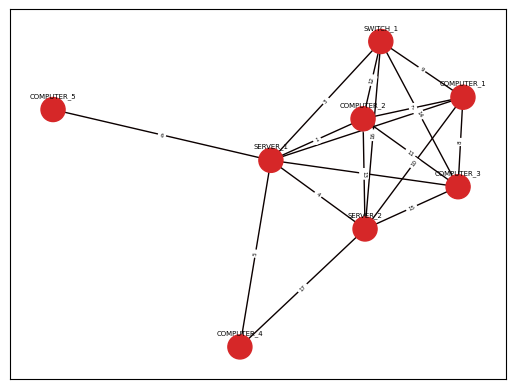

In [18]:
import random


outputs = []
fails = []
for i in range(DATASET_SIZE):

    laydown_save_path = Path("../data") / "datasets" / "notebook_generated_dataset" / f"{i}.yaml"
    generator = NetworkGenerator(graph_size=random.randint(NUMBER_OF_NODES[0], NUMBER_OF_NODES[1]), training_config_path=TRAINING_CONFIG_PATH, random_seed=1729, services=SERVICE_NAMES, ports=PORTS_LIST, pretrained_llm=openai)
    output = generator.run_end_to_end(laydown_save_path=laydown_save_path)
    outputs.append(output)
    # except Exception as e:
    #     try:
    #         fails.append(str(e))
    #     except:
    #         pass

    print(f"\nPROGRESS -------> {i + 1} of {DATASET_SIZE} datasets generated\n")

In [19]:
print(outputs[0])

Data(edge_index=[2, 36], id=[36], num_nodes=8, x=[8, 6], reasoning='The node SERVER_1 is the most critical node in the network as it is connected to multiple other nodes like computers, switches, and servers. If SERVER_1 is compromised, it can lead to a widespread attack and further spread to other nodes. Taking defensive action on SERVER_1 to ensure its security and prevent any potential attacks.', chosen_node='SERVER_1', node_property='HARDWARE', property_action='TURN_ON', service_name='NONE', laydown_filename='0.yaml')


In [20]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
batch = Batch.from_data_list(outputs)
torch.save(batch, "../data/datasets/notebook_generated_dataset/dataset.pt")